# RoBERTa + ANLI Curriculum Training — v10
**Architecture 100% from scratch · Curriculum stages aligned to ANLI paper (Nie et al. 2020)**

### What changed from v9 -> v10
All changes are driven by the SVG analysis diagram (`roberta_anli_analysis.svg`):

| Area | v9 (deviation) | v10 (fixed — per SVG) |
|---|---|---|
| Stage 2 parameter freezing | Embeddings frozen | **No freeze — all params trainable from Stage 2** |

Everything else remains identical to v9.

### Expected test accuracy (per SVG)
- ANLI R1: ~65%  (paper RoBERTa-large: 73.6%)
- ANLI R2: ~48%  (paper: 48.9%)
- ANLI R3: ~42%  (paper: 44.4%)


## Cell 0 — Hardware Checks

In [1]:
import torch, platform

if torch.xpu.is_available():
    print(f'XPU device  : {torch.xpu.get_device_name(0)}')
    print(f'XPU count   : {torch.xpu.device_count()}')
    print(f'XPU props   : {torch.xpu.get_device_properties(0)}')
elif torch.cuda.is_available():
    print(f'CUDA device : {torch.cuda.get_device_name(0)}')
else:
    print('CPU only')
print(f'System : {platform.processor()}')


XPU device  : Intel(R) Arc(TM) 130V GPU (8GB)
XPU count   : 1
XPU props   : _XpuDeviceProperties(name='Intel(R) Arc(TM) 130V GPU (8GB)', platform_name='Intel(R) oneAPI Unified Runtime over Level-Zero V2', type='gpu', device_id=0x64A0, uuid=8680a064-0400-0000-0002-000000000000, driver_version='1.5.30513', total_memory=8147MB, local_mem_size=128KB, max_compute_units=48, memory_clock_rate=0MHz, memory_bus_width=64-bit, gpu_eu_count=48, gpu_subslice_count=6, max_work_group_size=1024, max_num_sub_groups=64, sub_group_sizes=[16 32], has_fp16=1, has_fp64=1, has_atomic64=1)
System : Intel64 Family 6 Model 189 Stepping 1, GenuineIntel


In [2]:
# fp16 smoke-test
_dev = 'xpu' if torch.xpu.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
x = torch.randn(32, 128, 768, dtype=torch.float16).to(_dev)
y = torch.randn(32, 128, 768, dtype=torch.float16).to(_dev)
z = torch.matmul(x, y.transpose(-1, -2))
print(f'fp16 matmul ok — device={_dev}')
del x, y, z
if torch.xpu.is_available(): torch.xpu.empty_cache()
elif torch.cuda.is_available(): torch.cuda.empty_cache()


fp16 matmul ok — device=xpu


## Cell 0b — Install Dependencies
> Run once, then restart kernel.

In [3]:
import subprocess, sys

subprocess.run([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pip'], check=True)

r1 = subprocess.run(
    [sys.executable, '-m', 'pip', 'install',
     'torch', 'torchvision', 'torchaudio',
     '--index-url', 'https://download.pytorch.org/whl/xpu'],
    capture_output=True, text=True)
print(r1.stdout[-2000:])

r2 = subprocess.run(
    [sys.executable, '-m', 'pip', 'install',
     'transformers==4.47.1', 'datasets', 'accelerate',
     'scikit-learn', 'matplotlib', 'seaborn', 'ipywidgets'],
    capture_output=True, text=True)
print(r2.stdout[-2000:])

print('\nDone — restart kernel before Cell 1')


thon\python310\lib\site-packages (from torch) (2025.3.2)

nt already satisfied: intel-openmp==2025.3.2 in c:\users\anind\appdata\local\programs\python\python310\lib\site-packages (from torch>=2.0.0->accelerate) (2025.3.2)


Done — restart kernel before Cell 1


## Cell 1 — Imports & Device Setup

In [4]:
import os
os.environ['USE_TF'] = '0'
os.environ['TRANSFORMERS_NO_TF'] = '1'

import math
from typing import List, Optional, Tuple, Union

import torch
import torch.utils.checkpoint
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import BCEWithLogitsLoss, CrossEntropyLoss, MSELoss

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from datasets import load_dataset, concatenate_datasets
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    RobertaConfig,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    PreTrainedModel,
)
from transformers.activations import ACT2FN
from transformers.modeling_outputs import (
    BaseModelOutputWithPoolingAndCrossAttentions,
    BaseModelOutputWithPastAndCrossAttentions,
    SequenceClassifierOutput,
)
from transformers.pytorch_utils import apply_chunking_to_forward
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

if torch.xpu.is_available():
    device   = torch.device('xpu')
    gpu_name = torch.xpu.get_device_name(0)
elif torch.cuda.is_available():
    device   = torch.device('cuda')
    gpu_name = torch.cuda.get_device_name(0)
else:
    device   = torch.device('cpu')
    gpu_name = 'CPU only'

print(f'Torch   : {torch.__version__}')
print(f'Device  : {device}  ({gpu_name})')


Torch   : 2.12.0+xpu
Device  : xpu  (Intel(R) Arc(TM) 130V GPU (8GB))


## Cell 1b — RoBERTa Architecture (HF v4.47.1 clone)

In [5]:
def create_position_ids_from_input_ids(input_ids, padding_idx, past_key_values_length=0):
    mask = input_ids.ne(padding_idx).int()
    incremental_indices = (torch.cumsum(mask, dim=1).type_as(mask) + past_key_values_length) * mask
    return incremental_indices.long() + padding_idx


class RobertaEmbeddings(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.word_embeddings = nn.Embedding(config.vocab_size, config.hidden_size, padding_idx=config.pad_token_id)
        self.position_embeddings = nn.Embedding(config.max_position_embeddings, config.hidden_size)
        self.token_type_embeddings = nn.Embedding(config.type_vocab_size, config.hidden_size)
        self.LayerNorm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.position_embedding_type = getattr(config, 'position_embedding_type', 'absolute')
        self.register_buffer('position_ids', torch.arange(config.max_position_embeddings).expand((1, -1)), persistent=False)
        self.register_buffer('token_type_ids', torch.zeros(self.position_ids.size(), dtype=torch.long), persistent=False)
        self.padding_idx = config.pad_token_id
        self.position_embeddings = nn.Embedding(config.max_position_embeddings, config.hidden_size, padding_idx=self.padding_idx)

    def forward(self, input_ids=None, token_type_ids=None, position_ids=None, inputs_embeds=None, past_key_values_length=0):
        if position_ids is None:
            if input_ids is not None:
                position_ids = create_position_ids_from_input_ids(input_ids, self.padding_idx, past_key_values_length)
            else:
                position_ids = self.create_position_ids_from_inputs_embeds(inputs_embeds)
        input_shape = input_ids.size() if input_ids is not None else inputs_embeds.size()[:-1]
        seq_length = input_shape[1]
        if token_type_ids is None:
            if hasattr(self, 'token_type_ids'):
                buffered = self.token_type_ids[:, :seq_length]
                token_type_ids = buffered.expand(input_shape[0], seq_length)
            else:
                token_type_ids = torch.zeros(input_shape, dtype=torch.long, device=self.position_ids.device)
        if inputs_embeds is None:
            inputs_embeds = self.word_embeddings(input_ids)
        token_type_embeddings = self.token_type_embeddings(token_type_ids)
        embeddings = inputs_embeds + token_type_embeddings
        if self.position_embedding_type == 'absolute':
            embeddings += self.position_embeddings(position_ids)
        embeddings = self.LayerNorm(embeddings)
        embeddings = self.dropout(embeddings)
        return embeddings

    def create_position_ids_from_inputs_embeds(self, inputs_embeds):
        input_shape = inputs_embeds.size()[:-1]
        sequence_length = input_shape[1]
        position_ids = torch.arange(self.padding_idx + 1, sequence_length + self.padding_idx + 1,
                                    dtype=torch.long, device=inputs_embeds.device)
        return position_ids.unsqueeze(0).expand(input_shape)


class RobertaSelfAttention(nn.Module):
    def __init__(self, config, position_embedding_type=None):
        super().__init__()
        if config.hidden_size % config.num_attention_heads != 0 and not hasattr(config, 'embedding_size'):
            raise ValueError('hidden_size not divisible by num_attention_heads')
        self.num_attention_heads = config.num_attention_heads
        self.attention_head_size = int(config.hidden_size / config.num_attention_heads)
        self.all_head_size = self.num_attention_heads * self.attention_head_size
        self.query = nn.Linear(config.hidden_size, self.all_head_size)
        self.key = nn.Linear(config.hidden_size, self.all_head_size)
        self.value = nn.Linear(config.hidden_size, self.all_head_size)
        self.dropout = nn.Dropout(config.attention_probs_dropout_prob)
        self.position_embedding_type = position_embedding_type or getattr(config, 'position_embedding_type', 'absolute')
        if self.position_embedding_type in ('relative_key', 'relative_key_query'):
            self.max_position_embeddings = config.max_position_embeddings
            self.distance_embedding = nn.Embedding(2 * config.max_position_embeddings - 1, self.attention_head_size)
        self.is_decoder = config.is_decoder

    def transpose_for_scores(self, x):
        new_shape = x.size()[:-1] + (self.num_attention_heads, self.attention_head_size)
        return x.view(new_shape).permute(0, 2, 1, 3)

    def forward(self, hidden_states, attention_mask=None, head_mask=None,
                encoder_hidden_states=None, encoder_attention_mask=None,
                past_key_value=None, output_attentions=False):
        mixed_query_layer = self.query(hidden_states)
        is_cross_attention = encoder_hidden_states is not None
        if is_cross_attention and past_key_value is not None:
            key_layer, value_layer = past_key_value[0], past_key_value[1]
            attention_mask = encoder_attention_mask
        elif is_cross_attention:
            key_layer = self.transpose_for_scores(self.key(encoder_hidden_states))
            value_layer = self.transpose_for_scores(self.value(encoder_hidden_states))
            attention_mask = encoder_attention_mask
        elif past_key_value is not None:
            key_layer = self.transpose_for_scores(self.key(hidden_states))
            value_layer = self.transpose_for_scores(self.value(hidden_states))
            key_layer = torch.cat([past_key_value[0], key_layer], dim=2)
            value_layer = torch.cat([past_key_value[1], value_layer], dim=2)
        else:
            key_layer = self.transpose_for_scores(self.key(hidden_states))
            value_layer = self.transpose_for_scores(self.value(hidden_states))
        query_layer = self.transpose_for_scores(mixed_query_layer)
        if self.is_decoder:
            past_key_value = (key_layer, value_layer)
        attention_scores = torch.matmul(query_layer, key_layer.transpose(-1, -2))
        if self.position_embedding_type in ('relative_key', 'relative_key_query'):
            query_length, key_length = query_layer.shape[2], key_layer.shape[2]
            use_cache = past_key_value is not None
            if use_cache:
                position_ids_l = torch.tensor(key_length - 1, dtype=torch.long, device=hidden_states.device).view(-1, 1)
            else:
                position_ids_l = torch.arange(query_length, dtype=torch.long, device=hidden_states.device).view(-1, 1)
            position_ids_r = torch.arange(key_length, dtype=torch.long, device=hidden_states.device).view(1, -1)
            distance = position_ids_l - position_ids_r
            positional_embedding = self.distance_embedding(distance + self.max_position_embeddings - 1).to(dtype=query_layer.dtype)
            if self.position_embedding_type == 'relative_key':
                attention_scores = attention_scores + torch.einsum('bhld,lrd->bhlr', query_layer, positional_embedding)
            elif self.position_embedding_type == 'relative_key_query':
                attention_scores = (attention_scores
                    + torch.einsum('bhld,lrd->bhlr', query_layer, positional_embedding)
                    + torch.einsum('bhrd,lrd->bhlr', key_layer, positional_embedding))
        attention_scores = attention_scores / math.sqrt(self.attention_head_size)
        if attention_mask is not None:
            attention_scores = attention_scores + attention_mask
        attention_probs = nn.functional.softmax(attention_scores, dim=-1)
        attention_probs = self.dropout(attention_probs)
        if head_mask is not None:
            attention_probs = attention_probs * head_mask
        context_layer = torch.matmul(attention_probs, value_layer)
        context_layer = context_layer.permute(0, 2, 1, 3).contiguous()
        context_layer = context_layer.view(context_layer.size()[:-2] + (self.all_head_size,))
        outputs = (context_layer, attention_probs) if output_attentions else (context_layer,)
        if self.is_decoder:
            outputs = outputs + (past_key_value,)
        return outputs


class RobertaSelfOutput(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.LayerNorm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
    def forward(self, hidden_states, input_tensor):
        hidden_states = self.dense(hidden_states)
        hidden_states = self.dropout(hidden_states)
        return self.LayerNorm(hidden_states + input_tensor)


class RobertaAttention(nn.Module):
    def __init__(self, config, position_embedding_type=None):
        super().__init__()
        self.self = RobertaSelfAttention(config, position_embedding_type=position_embedding_type)
        self.output = RobertaSelfOutput(config)
        self.pruned_heads = set()
    def forward(self, hidden_states, attention_mask=None, head_mask=None,
                encoder_hidden_states=None, encoder_attention_mask=None,
                past_key_value=None, output_attentions=False):
        self_outputs = self.self(hidden_states, attention_mask, head_mask,
                                 encoder_hidden_states, encoder_attention_mask,
                                 past_key_value, output_attentions)
        attention_output = self.output(self_outputs[0], hidden_states)
        return (attention_output,) + self_outputs[1:]


class RobertaIntermediate(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.dense = nn.Linear(config.hidden_size, config.intermediate_size)
        self.intermediate_act_fn = ACT2FN[config.hidden_act] if isinstance(config.hidden_act, str) else config.hidden_act
    def forward(self, hidden_states):
        return self.intermediate_act_fn(self.dense(hidden_states))


class RobertaOutput(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.dense = nn.Linear(config.intermediate_size, config.hidden_size)
        self.LayerNorm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
    def forward(self, hidden_states, input_tensor):
        hidden_states = self.dense(hidden_states)
        hidden_states = self.dropout(hidden_states)
        return self.LayerNorm(hidden_states + input_tensor)


class RobertaLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.chunk_size_feed_forward = config.chunk_size_feed_forward
        self.seq_len_dim = 1
        self.attention = RobertaAttention(config)
        self.is_decoder = config.is_decoder
        self.add_cross_attention = config.add_cross_attention
        if self.add_cross_attention:
            if not self.is_decoder:
                raise ValueError('cross-attention only allowed in decoder mode')
            self.crossattention = RobertaAttention(config, position_embedding_type='absolute')
        self.intermediate = RobertaIntermediate(config)
        self.output = RobertaOutput(config)
    def forward(self, hidden_states, attention_mask=None, head_mask=None,
                encoder_hidden_states=None, encoder_attention_mask=None,
                past_key_value=None, output_attentions=False):
        self_attn_past_key_value = past_key_value[:2] if past_key_value is not None else None
        self_attention_outputs = self.attention(hidden_states, attention_mask, head_mask,
                                                output_attentions=output_attentions,
                                                past_key_value=self_attn_past_key_value)
        attention_output = self_attention_outputs[0]
        if self.is_decoder:
            outputs = self_attention_outputs[1:-1]
            present_key_value = self_attention_outputs[-1]
        else:
            outputs = self_attention_outputs[1:]
        if self.is_decoder and encoder_hidden_states is not None:
            if not hasattr(self, 'crossattention'):
                raise ValueError('Cross-attention layers missing.')
            cross_attn_past_key_value = past_key_value[-2:] if past_key_value is not None else None
            cross_attention_outputs = self.crossattention(attention_output, attention_mask, head_mask,
                                                          encoder_hidden_states, encoder_attention_mask,
                                                          cross_attn_past_key_value, output_attentions)
            attention_output = cross_attention_outputs[0]
            outputs = outputs + cross_attention_outputs[1:-1]
            present_key_value = present_key_value + cross_attention_outputs[-1]
        layer_output = apply_chunking_to_forward(self.feed_forward_chunk,
                                                 self.chunk_size_feed_forward,
                                                 self.seq_len_dim, attention_output)
        outputs = (layer_output,) + outputs
        if self.is_decoder:
            outputs = outputs + (present_key_value,)
        return outputs
    def feed_forward_chunk(self, attention_output):
        return self.output(self.intermediate(attention_output), attention_output)


class RobertaEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.layer = nn.ModuleList([RobertaLayer(config) for _ in range(config.num_hidden_layers)])
        self.gradient_checkpointing = False
    def forward(self, hidden_states, attention_mask=None, head_mask=None,
                encoder_hidden_states=None, encoder_attention_mask=None,
                past_key_values=None, use_cache=None, output_attentions=False,
                output_hidden_states=False, return_dict=True):
        all_hidden_states = () if output_hidden_states else None
        all_self_attentions = () if output_attentions else None
        all_cross_attentions = () if output_attentions and self.config.add_cross_attention else None
        if self.gradient_checkpointing and self.training:
            use_cache = False
        next_decoder_cache = () if use_cache else None
        for i, layer_module in enumerate(self.layer):
            if output_hidden_states:
                all_hidden_states = all_hidden_states + (hidden_states,)
            layer_head_mask = head_mask[i] if head_mask is not None else None
            past_key_value = past_key_values[i] if past_key_values is not None else None
            if self.gradient_checkpointing and self.training:
                layer_outputs = self._gradient_checkpointing_func(
                    layer_module.__call__, hidden_states, attention_mask, layer_head_mask,
                    encoder_hidden_states, encoder_attention_mask, past_key_value, output_attentions)
            else:
                layer_outputs = layer_module(hidden_states, attention_mask, layer_head_mask,
                                            encoder_hidden_states, encoder_attention_mask,
                                            past_key_value, output_attentions)
            hidden_states = layer_outputs[0]
            if use_cache:
                next_decoder_cache += (layer_outputs[-1],)
            if output_attentions:
                all_self_attentions = all_self_attentions + (layer_outputs[1],)
                if self.config.add_cross_attention:
                    all_cross_attentions = all_cross_attentions + (layer_outputs[2],)
        if output_hidden_states:
            all_hidden_states = all_hidden_states + (hidden_states,)
        if not return_dict:
            return tuple(v for v in [hidden_states, next_decoder_cache, all_hidden_states,
                                     all_self_attentions, all_cross_attentions] if v is not None)
        return BaseModelOutputWithPastAndCrossAttentions(
            last_hidden_state=hidden_states, past_key_values=next_decoder_cache,
            hidden_states=all_hidden_states, attentions=all_self_attentions,
            cross_attentions=all_cross_attentions)


class RobertaPooler(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.activation = nn.Tanh()
    def forward(self, hidden_states):
        return self.activation(self.dense(hidden_states[:, 0]))


class RobertaPreTrainedModel(PreTrainedModel):
    config_class = RobertaConfig
    base_model_prefix = 'roberta'
    supports_gradient_checkpointing = True
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            module.weight.data.normal_(mean=0.0, std=self.config.initializer_range)
            if module.bias is not None:
                module.bias.data.zero_()
        elif isinstance(module, nn.Embedding):
            module.weight.data.normal_(mean=0.0, std=self.config.initializer_range)
            if module.padding_idx is not None:
                module.weight.data[module.padding_idx].zero_()
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)


class RobertaModel(RobertaPreTrainedModel):
    _no_split_modules = ['RobertaEmbeddings', 'RobertaLayer']
    def __init__(self, config, add_pooling_layer=True):
        super().__init__(config)
        self.config = config
        self.embeddings = RobertaEmbeddings(config)
        self.encoder = RobertaEncoder(config)
        self.pooler = RobertaPooler(config) if add_pooling_layer else None
        self.post_init()
    def get_input_embeddings(self):
        return self.embeddings.word_embeddings
    def set_input_embeddings(self, value):
        self.embeddings.word_embeddings = value
    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None,
                position_ids=None, head_mask=None, inputs_embeds=None,
                encoder_hidden_states=None, encoder_attention_mask=None,
                past_key_values=None, use_cache=None, output_attentions=None,
                output_hidden_states=None, return_dict=None):
        output_attentions = output_attentions if output_attentions is not None else self.config.output_attentions
        output_hidden_states = output_hidden_states if output_hidden_states is not None else self.config.output_hidden_states
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict
        use_cache = False if not self.config.is_decoder else (use_cache if use_cache is not None else self.config.use_cache)
        if input_ids is not None and inputs_embeds is not None:
            raise ValueError('Specify either input_ids or inputs_embeds, not both')
        elif input_ids is not None:
            self.warn_if_padding_and_no_attention_mask(input_ids, attention_mask)
            input_shape = input_ids.size()
        elif inputs_embeds is not None:
            input_shape = inputs_embeds.size()[:-1]
        else:
            raise ValueError('Specify either input_ids or inputs_embeds')
        batch_size, seq_length = input_shape
        device = input_ids.device if input_ids is not None else inputs_embeds.device
        past_key_values_length = past_key_values[0][0].shape[2] if past_key_values is not None else 0
        if token_type_ids is None:
            if hasattr(self.embeddings, 'token_type_ids'):
                buffered = self.embeddings.token_type_ids[:, :seq_length]
                token_type_ids = buffered.expand(batch_size, seq_length)
            else:
                token_type_ids = torch.zeros(input_shape, dtype=torch.long, device=device)
        embedding_output = self.embeddings(input_ids=input_ids, position_ids=position_ids,
                                           token_type_ids=token_type_ids, inputs_embeds=inputs_embeds,
                                           past_key_values_length=past_key_values_length)
        if attention_mask is None:
            attention_mask = torch.ones((batch_size, seq_length + past_key_values_length), device=device)
        extended_attention_mask = self.get_extended_attention_mask(attention_mask, input_shape)
        if self.config.is_decoder and encoder_hidden_states is not None:
            enc_bs, enc_sl, _ = encoder_hidden_states.size()
            if encoder_attention_mask is None:
                encoder_attention_mask = torch.ones((enc_bs, enc_sl), device=device)
            encoder_extended_attention_mask = self.invert_attention_mask(encoder_attention_mask)
        else:
            encoder_extended_attention_mask = None
        head_mask = self.get_head_mask(head_mask, self.config.num_hidden_layers)
        encoder_outputs = self.encoder(embedding_output, attention_mask=extended_attention_mask,
                                       head_mask=head_mask, encoder_hidden_states=encoder_hidden_states,
                                       encoder_attention_mask=encoder_extended_attention_mask,
                                       past_key_values=past_key_values, use_cache=use_cache,
                                       output_attentions=output_attentions,
                                       output_hidden_states=output_hidden_states, return_dict=return_dict)
        sequence_output = encoder_outputs[0]
        pooled_output = self.pooler(sequence_output) if self.pooler is not None else None
        if not return_dict:
            return (sequence_output, pooled_output) + encoder_outputs[1:]
        return BaseModelOutputWithPoolingAndCrossAttentions(
            last_hidden_state=sequence_output, pooler_output=pooled_output,
            past_key_values=encoder_outputs.past_key_values,
            hidden_states=encoder_outputs.hidden_states,
            attentions=encoder_outputs.attentions,
            cross_attentions=encoder_outputs.cross_attentions)


class RobertaClassificationHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        classifier_dropout = config.classifier_dropout if config.classifier_dropout is not None else config.hidden_dropout_prob
        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.dropout = nn.Dropout(classifier_dropout)
        self.out_proj = nn.Linear(config.hidden_size, config.num_labels)
    def forward(self, features, **kwargs):
        x = features[:, 0, :]
        x = self.dropout(x)
        x = self.dense(x)
        x = torch.tanh(x)
        x = self.dropout(x)
        return self.out_proj(x)


class RobertaForSequenceClassification(RobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.config = config
        self.roberta = RobertaModel(config, add_pooling_layer=False)
        self.classifier = RobertaClassificationHead(config)
        self.post_init()
    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None,
                position_ids=None, head_mask=None, inputs_embeds=None, labels=None,
                output_attentions=None, output_hidden_states=None, return_dict=None, **kwargs):
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict
        outputs = self.roberta(input_ids, attention_mask=attention_mask,
                               token_type_ids=token_type_ids, position_ids=position_ids,
                               head_mask=head_mask, inputs_embeds=inputs_embeds,
                               output_attentions=output_attentions,
                               output_hidden_states=output_hidden_states, return_dict=return_dict)
        logits = self.classifier(outputs[0])
        loss = None
        if labels is not None:
            if self.config.problem_type is None:
                if self.num_labels == 1:
                    self.config.problem_type = 'regression'
                elif self.num_labels > 1 and (labels.dtype == torch.long or labels.dtype == torch.int):
                    self.config.problem_type = 'single_label_classification'
                else:
                    self.config.problem_type = 'multi_label_classification'
            if self.config.problem_type == 'regression':
                loss_fct = MSELoss()
                loss = loss_fct(logits.squeeze(), labels.squeeze()) if self.num_labels == 1 else loss_fct(logits, labels)
            elif self.config.problem_type == 'single_label_classification':
                loss = CrossEntropyLoss()(logits.view(-1, self.num_labels), labels.view(-1))
            elif self.config.problem_type == 'multi_label_classification':
                loss = BCEWithLogitsLoss()(logits, labels)
        if not return_dict:
            output = (logits,) + outputs[2:]
            return ((loss,) + output) if loss is not None else output
        return SequenceClassifierOutput(loss=loss, logits=logits,
                                        hidden_states=outputs.hidden_states, attentions=outputs.attentions)


print('All modules defined — HF v4.47.1 clone (v10)')


All modules defined — HF v4.47.1 clone (v10)


## Cell 2 — Load roberta-base Weights into Custom Architecture

In [6]:
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

config = RobertaConfig(
    vocab_size=50265, hidden_size=768, num_hidden_layers=12,
    num_attention_heads=12, intermediate_size=3072, hidden_act='gelu',
    hidden_dropout_prob=0.1, attention_probs_dropout_prob=0.1,
    max_position_embeddings=514, type_vocab_size=1, layer_norm_eps=1e-5,
    pad_token_id=1, classifier_dropout=None, num_labels=3,
    is_decoder=False, add_cross_attention=False, chunk_size_feed_forward=0,
)

model = RobertaForSequenceClassification(config)
print(f'Custom model parameters : {sum(p.numel() for p in model.parameters()):,}')

print('Downloading roberta-base weights...')
hf_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=3)
hf_state = hf_model.state_dict()

missing, unexpected = model.load_state_dict(hf_state, strict=True)
assert len(missing) == 0, f'Missing keys ({len(missing)}): {missing[:5]}'
assert len(unexpected) == 0, f'Unexpected keys ({len(unexpected)}): {unexpected[:5]}'

del hf_model
import gc; gc.collect()

model.to(device)
print('roberta-base weights loaded — strict=True, 0 missing, 0 unexpected')

model.eval()
_ids = torch.ones(1, 128, dtype=torch.long).to(device)
_mask = torch.ones(1, 128, dtype=torch.long).to(device)
with torch.no_grad():
    out = model(input_ids=_ids, attention_mask=_mask)
assert out.logits.shape == (1, 3)
print(f'Logits shape : {out.logits.shape} — forward pass verified')


Custom model parameters : 124,647,939


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


roberta-base weights loaded — strict=True, 0 missing, 0 unexpected
Logits shape : torch.Size([1, 3]) — forward pass verified


## Cell 2b — Numerical Equivalence Test

In [ ]:
from transformers import RobertaForSequenceClassification as HF_Roberta

hf_ref = HF_Roberta.from_pretrained('roberta-base', num_labels=3)
hf_ref.load_state_dict(model.state_dict(), strict=True)
hf_ref.to(device).eval()

torch.manual_seed(0)
test_ids = torch.randint(5, 50265, (4, 64)).to(device)
test_mask = torch.ones(4, 64, dtype=torch.long).to(device)

model.eval()
with torch.no_grad():
    our_logits = model(input_ids=test_ids, attention_mask=test_mask).logits
    hf_logits = hf_ref(input_ids=test_ids, attention_mask=test_mask).logits

max_diff = (our_logits - hf_logits).abs().max().item()
print(f'Max absolute logit difference vs HF reference: {max_diff:.2e}')
assert max_diff < 1e-3, f'Logits diverge! max_diff={max_diff}'
print('Numerically equivalent to HF RobertaForSequenceClassification')

del hf_ref
import gc; gc.collect()


## Cell 3 — Load & Tokenize Datasets

In [7]:
snli = load_dataset('stanfordnlp/snli')
mnli = load_dataset('nyu-mll/multi_nli')
anli = load_dataset('facebook/anli')
fever = load_dataset('pietrolesci/nli_fever')

MAX_LEN = 128

def preprocess_snli(examples):
    tok = tokenizer(examples['premise'], examples['hypothesis'],
                    truncation=True, padding='max_length', max_length=MAX_LEN, verbose=False)
    tok['labels'] = [l if l != -1 else 1 for l in examples['label']]
    return tok

def preprocess_mnli(examples):
    tok = tokenizer(examples['premise'], examples['hypothesis'],
                    truncation=True, padding='max_length', max_length=MAX_LEN, verbose=False)
    tok['labels'] = list(examples['label'])
    return tok

preprocess_fever = preprocess_mnli
preprocess_anli = preprocess_mnli

COLS = ['input_ids', 'attention_mask', 'labels']

snli_train = snli['train'].filter(lambda x: x['label'] != -1).map(
    preprocess_snli, batched=True, remove_columns=snli['train'].column_names)
snli_dev = snli['validation'].filter(lambda x: x['label'] != -1).map(
    preprocess_snli, batched=True, remove_columns=snli['validation'].column_names)
mnli_train = mnli['train'].map(
    preprocess_mnli, batched=True, remove_columns=mnli['train'].column_names)
mnli_dev = mnli['validation_matched'].map(
    preprocess_mnli, batched=True, remove_columns=mnli['validation_matched'].column_names)
fever_train = fever['train'].map(
    preprocess_fever, batched=True, remove_columns=fever['train'].column_names)

anli_r1_tr = anli['train_r1'].map(preprocess_anli, batched=True, remove_columns=anli['train_r1'].column_names)
anli_r2_tr = anli['train_r2'].map(preprocess_anli, batched=True, remove_columns=anli['train_r2'].column_names)
anli_r3_tr = anli['train_r3'].map(preprocess_anli, batched=True, remove_columns=anli['train_r3'].column_names)
anli_r1_dev = anli['dev_r1'].map(preprocess_anli, batched=True, remove_columns=anli['dev_r1'].column_names)
anli_r2_dev = anli['dev_r2'].map(preprocess_anli, batched=True, remove_columns=anli['dev_r2'].column_names)
anli_r3_dev = anli['dev_r3'].map(preprocess_anli, batched=True, remove_columns=anli['dev_r3'].column_names)
anli_r1_tst = anli['test_r1'].map(preprocess_anli, batched=True, remove_columns=anli['test_r1'].column_names)
anli_r2_tst = anli['test_r2'].map(preprocess_anli, batched=True, remove_columns=anli['test_r2'].column_names)
anli_r3_tst = anli['test_r3'].map(preprocess_anli, batched=True, remove_columns=anli['test_r3'].column_names)

all_ds = [snli_train, snli_dev, mnli_train, mnli_dev, fever_train,
          anli_r1_tr, anli_r2_tr, anli_r3_tr,
          anli_r1_dev, anli_r2_dev, anli_r3_dev,
          anli_r1_tst, anli_r2_tst, anli_r3_tst]
for ds in all_ds:
    ds.set_format(type='torch', columns=COLS)

print('Datasets ready')
for name, ds in [('SNLI train', snli_train), ('MNLI train', mnli_train),
                 ('FEVER train', fever_train), ('ANLI R1 tr', anli_r1_tr),
                 ('ANLI R2 tr', anli_r2_tr), ('ANLI R3 tr', anli_r3_tr)]:
    print(f'  {name:<14}: {len(ds):>7,}')


Repo card metadata block was not found. Setting CardData to empty.


Datasets ready
  SNLI train    : 549,367
  MNLI train    : 392,702
  FEVER train   : 208,346
  ANLI R1 tr    :  16,946
  ANLI R2 tr    :  45,460
  ANLI R3 tr    : 100,459


## Cell 4 — Label Distribution Check

In [ ]:
for ds in all_ds: ds.reset_format()

for name, ds in [('SNLI train', snli_train), ('MNLI train', mnli_train),
                 ('FEVER train', fever_train),
                 ('ANLI R1', anli_r1_tr), ('ANLI R2', anli_r2_tr), ('ANLI R3', anli_r3_tr)]:
    c = Counter(ds['labels'])
    total = sum(c.values())
    print(f'{name}:')
    for label, lname in enumerate(['Entailment', 'Neutral', 'Contradiction']):
        n = c.get(label, 0)
        print(f'  {lname:<15}: {n:>7,}  ({n/total*100:.1f}%)')
    print()

for ds in all_ds: ds.set_format(type='torch', columns=COLS)
print('Format restored')


## Cell 5 — Training Helpers

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, preds)}


def make_trainer(model, train_ds, eval_ds, out_dir,
                 epochs=5, lr=2e-5, warmup_ratio=0.10,
                 max_steps=-1, patience=3, label_smoothing=0.05,
                 eval_strategy='epoch', eval_steps=None):
    steps_per_epoch = max(1, len(train_ds) // 64)
    total_steps = steps_per_epoch * epochs if max_steps == -1 else max_steps
    warmup = int(total_steps * warmup_ratio)
    save_strategy = eval_strategy
    args = TrainingArguments(
        output_dir=out_dir, num_train_epochs=epochs, max_steps=max_steps,
        per_device_train_batch_size=32, per_device_eval_batch_size=64,
        gradient_accumulation_steps=2, learning_rate=lr, warmup_steps=warmup,
        lr_scheduler_type='cosine', weight_decay=0.01,
        label_smoothing_factor=label_smoothing, max_grad_norm=1.0,
        eval_strategy=eval_strategy, eval_steps=eval_steps,
        save_strategy=save_strategy, save_steps=eval_steps,
        load_best_model_at_end=True, metric_for_best_model='accuracy',
        greater_is_better=True, fp16=True, bf16=False,
        logging_steps=200, report_to='none')
    return Trainer(model=model, args=args, train_dataset=train_ds,
                   eval_dataset=eval_ds, compute_metrics=compute_metrics,
                   callbacks=[EarlyStoppingCallback(early_stopping_patience=patience)])


def reload_checkpoint(path):
    m = RobertaForSequenceClassification.from_pretrained(path)
    return m.to(device)


print('Training helpers ready (v10)')
print(f'  max_length : {MAX_LEN}')


Training helpers ready (v10)
  max_length : 128


## Cell 6 — Stage 1: SNLI + MNLI + FEVER-NLI
ALL parameters trainable — no freezing at any stage. Expected SNLI dev: ~88-91%.

In [9]:
import os, glob, shutil

stage1_train = concatenate_datasets([snli_train, mnli_train, fever_train]).shuffle(seed=42)
stage1_train.set_format(type='torch', columns=COLS)

for p in model.parameters(): p.requires_grad = True
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Stage 1 — all {trainable:,} parameters trainable')

if os.path.exists('./stage1_checkpoint'):
    print('Stage 1 checkpoint found — loading, skipping training')
    model = reload_checkpoint('./stage1_checkpoint')
else:
    spe = len(stage1_train) // 64
    print(f'  Train size  : {len(stage1_train):,}')
    print(f'  Steps/epoch : {spe:,}  |  Total (3ep): {spe*3:,}')
    t1 = make_trainer(model, stage1_train, snli_dev, './stage1_base_nli',
                      epochs=3, lr=2e-5, warmup_ratio=0.06, patience=3,
                      label_smoothing=0.05, eval_strategy='epoch')
    t1.train()
    print('Stage 1 complete')
    best = t1.state.best_model_checkpoint
    src = best if best else sorted(glob.glob('./stage1_base_nli/checkpoint-*'))[-1]
    shutil.copytree(src, './stage1_checkpoint', dirs_exist_ok=True)
    print('Saved -> ./stage1_checkpoint')

model = reload_checkpoint('./stage1_checkpoint')
print('Stage 1 model ready')


Stage 1 — all 124,647,939 parameters trainable
Stage 1 checkpoint found — loading, skipping training
Stage 1 model ready


## Cell 7 — Stage 2: ANLI R1 (all parameters trainable)
All parameters trainable — no freezing.
Final hyperparameters: lr=8e-6, epochs=6, patience=5, label_smoothing=0.0, eval_steps=25.
Best R1 dev accuracy achieved: **49.5%**.

In [10]:
import gc, glob, shutil, os

gc.collect()
if torch.xpu.is_available(): torch.xpu.empty_cache()
elif torch.cuda.is_available(): torch.cuda.empty_cache()

anli_r1_up = anli_r1_tr.shuffle(seed=42)
anli_r1_up.set_format(type='torch', columns=COLS)

if os.path.exists('./stage2_checkpoint'):
    print('Stage 2 checkpoint found — loading, skipping training')
    model = reload_checkpoint('./stage2_checkpoint')
else:
    if os.path.exists('./stage2_r1'): shutil.rmtree('./stage2_r1')
    for p in model.parameters(): p.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    print(f'Stage 2 — ALL {trainable:,} parameters trainable, {frozen} frozen')
    assert frozen == 0, 'Expected 0 frozen parameters at Stage 2!'
    print(f'  Train : ANLI R1 {len(anli_r1_up):,}  |  Eval : R1 dev {len(anli_r1_dev):,}')
    t2 = make_trainer(model, anli_r1_up, anli_r1_dev, './stage2_r1',
                      epochs=6, lr=8e-6, warmup_ratio=0.06, patience=5,
                      label_smoothing=0.0, eval_strategy='steps', eval_steps=25)
    t2.train()
    print('Stage 2 complete')
    best = t2.state.best_model_checkpoint
    src = best if best else sorted(glob.glob('./stage2_r1/checkpoint-*'))[-1]
    shutil.copytree(src, './stage2_checkpoint', dirs_exist_ok=True)
    print('Saved -> ./stage2_checkpoint')

model = reload_checkpoint('./stage2_checkpoint')
print('Stage 2 model ready')


Stage 2 checkpoint found — loading, skipping training
Stage 2 model ready


## Cell 8 — Stage 3: ANLI R1 + R2 (x20)
Upsampling matches paper. Expected R2 dev: ~48-56%.

In [11]:
import gc, glob, shutil, os

gc.collect()
if torch.xpu.is_available(): torch.xpu.empty_cache()
elif torch.cuda.is_available(): torch.cuda.empty_cache()

if os.path.exists('./stage3_r1r2'): shutil.rmtree('./stage3_r1r2')

for p in model.parameters(): p.requires_grad = True
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Stage 3 — all {trainable:,} parameters trainable')

anli_r2_up = concatenate_datasets([anli_r2_tr] * 20)
anli_r2_up.set_format(type='torch', columns=COLS)
anli_r1_r2_up = concatenate_datasets([anli_r1_up, anli_r2_up]).shuffle(seed=42)
anli_r1_r2_up.set_format(type='torch', columns=COLS)
anli_r1_r2_dev = concatenate_datasets([anli_r1_dev, anli_r2_dev])
anli_r1_r2_dev.set_format(type='torch', columns=COLS)

print(f'  R1: {len(anli_r1_up):,}  R2x20: {len(anli_r2_up):,}  Total: {len(anli_r1_r2_up):,}')
t3 = make_trainer(model, anli_r1_r2_up, anli_r1_r2_dev, './stage3_r1r2',
                  epochs=6, lr=5e-6, warmup_ratio=0.15, patience=4,
                  label_smoothing=0.05, max_steps=50000,
                  eval_strategy='steps', eval_steps=500)
t3.train()
print('Stage 3 complete')

best = t3.state.best_model_checkpoint
src = best if best else sorted(glob.glob('./stage3_r1r2/checkpoint-*'))[-1]
shutil.copytree(src, './stage3_checkpoint', dirs_exist_ok=True)
print('Saved -> ./stage3_checkpoint')

model = reload_checkpoint('./stage3_checkpoint')
print('Stage 3 model ready')


Stage 3 — all 124,647,939 parameters trainable
  R1: 16,946  R2x20: 909,200  Total: 926,146


  0%|          | 0/50000 [00:00<?, ?it/s]

{'loss': 1.1119, 'grad_norm': 14.189946174621582, 'learning_rate': 1.3200000000000002e-07, 'epoch': 0.01}
{'loss': 1.0588, 'grad_norm': 17.42818832397461, 'learning_rate': 2.6533333333333333e-07, 'epoch': 0.03}


  0%|          | 0/32 [00:00<?, ?it/s]

{'eval_loss': 1.464552640914917, 'eval_accuracy': 0.4165, 'eval_runtime': 9.3325, 'eval_samples_per_second': 214.305, 'eval_steps_per_second': 3.429, 'epoch': 0.03}
{'loss': 1.0503, 'grad_norm': 15.67045783996582, 'learning_rate': 3.986666666666667e-07, 'epoch': 0.04}
{'loss': 1.0622, 'grad_norm': 19.071882247924805, 'learning_rate': 5.32e-07, 'epoch': 0.06}
{'loss': 1.0203, 'grad_norm': 16.83784294128418, 'learning_rate': 6.653333333333334e-07, 'epoch': 0.07}


...

{'eval_loss': 1.705957293510437, 'eval_accuracy': 0.533, 'eval_runtime': 9.289, 'eval_samples_per_second': 215.308, 'eval_steps_per_second': 3.445, 'epoch': 1.0}
{'loss': 0.4394, 'grad_norm': 39.97992706298828, 'learning_rate': 4.664354763478785e-06, 'epoch': 1.01}
{'loss': 0.4511, 'grad_norm': 17.17999267578125, 'learning_rate': 4.645620821359799e-06, 'epoch': 1.02}
{'loss': 0.4385, 'grad_norm': 16.391517639160156, 'learning_rate': 4.626417928807574e-06, 'epoch': 1.04}


  0%|          | 0/32 [00:00<?, ?it/s]

{'eval_loss': 1.6597709655761719, 'eval_accuracy': 0.541, 'eval_runtime': 9.1212, 'eval_samples_per_second': 219.268, 'eval_steps_per_second': 3.508, 'epoch': 1.04}
{'loss': 0.4322, 'grad_norm': 16.00682830810547, 'learning_rate': 4.606750282838043e-06, 'epoch': 1.05}
{'loss': 0.4344, 'grad_norm': 35.18587112426758, 'learning_rate': 4.586622182044418e-06, 'epoch': 1.06}


  0%|          | 0/32 [00:00<?, ?it/s]

{'eval_loss': 1.7631202936172485, 'eval_accuracy': 0.535, 'eval_runtime': 9.1924, 'eval_samples_per_second': 217.572, 'eval_steps_per_second': 3.481, 'epoch': 1.07}
{'train_runtime': 15949.7949, 'train_samples_per_second': 200.63, 'train_steps_per_second': 3.135, 'train_loss': 0.6713440426241967, 'epoch': 1.07}
Stage 3 complete
Saved -> ./stage3_checkpoint
Stage 3 model ready


## Cell 9 — Stage 4: ANLI R1 + R2 (x20) + R3 (x10)
Accumulative + LR decay. Lowest LR 4e-6. Expected R3 dev: ~42-50%.

In [12]:
import gc, glob, shutil, os

gc.collect()
if torch.xpu.is_available(): torch.xpu.empty_cache()
elif torch.cuda.is_available(): torch.cuda.empty_cache()

if os.path.exists('./stage4_r1r2r3'): shutil.rmtree('./stage4_r1r2r3')

for p in model.parameters(): p.requires_grad = True
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Stage 4 — all {trainable:,} parameters trainable')

anli_r3_up = concatenate_datasets([anli_r3_tr] * 10)
anli_r3_up.set_format(type='torch', columns=COLS)
anli_all_up = concatenate_datasets([anli_r1_up, anli_r2_up, anli_r3_up]).shuffle(seed=42)
anli_all_up.set_format(type='torch', columns=COLS)
anli_all_dev = concatenate_datasets([anli_r1_dev, anli_r2_dev, anli_r3_dev])
anli_all_dev.set_format(type='torch', columns=COLS)

print(f'  R1: {len(anli_r1_up):,}  R2x20: {len(anli_r2_up):,}  R3x10: {len(anli_r3_up):,}  Total: {len(anli_all_up):,}')
t4 = make_trainer(model, anli_all_up, anli_all_dev, './stage4_r1r2r3',
                  epochs=6, lr=4e-6, warmup_ratio=0.15, patience=4,
                  label_smoothing=0.05, max_steps=50000,
                  eval_strategy='steps', eval_steps=500)
t4.train()

model.save_pretrained('./roberta-anli-final')
tokenizer.save_pretrained('./roberta-anli-final')
print('Stage 4 complete — final model -> ./roberta-anli-final')

best = t4.state.best_model_checkpoint
src = best if best else sorted(glob.glob('./stage4_r1r2r3/checkpoint-*'))[-1]
shutil.copytree(src, './stage4_checkpoint', dirs_exist_ok=True)
print('Saved -> ./stage4_checkpoint')

model = reload_checkpoint('./stage4_checkpoint')
print('Stage 4 model ready')


Stage 4 — all 124,647,939 parameters trainable
  R1: 16,946  R2x20: 909,200  R3x10: 1,004,590  Total: 1,930,736


  0%|          | 0/50000 [00:00<?, ?it/s]

{'loss': 0.9225, 'grad_norm': 50.23289489746094, 'learning_rate': 1.0506666666666667e-07, 'epoch': 0.01}
{'loss': 0.9528, 'grad_norm': 48.94931411743164, 'learning_rate': 2.1173333333333332e-07, 'epoch': 0.01}


  0%|          | 0/50 [00:00<?, ?it/s]

{'eval_loss': 1.8229867219924927, 'eval_accuracy': 0.473125, 'eval_runtime': 14.6562, 'eval_samples_per_second': 218.337, 'eval_steps_per_second': 3.412, 'epoch': 0.02}
{'loss': 0.9153, 'grad_norm': 35.59956741333008, 'learning_rate': 3.184e-07, 'epoch': 0.02}
{'loss': 0.8864, 'grad_norm': 20.777097702026367, 'learning_rate': 4.245333333333333e-07, 'epoch': 0.03}
{'loss': 0.878, 'grad_norm': 21.603416442871094, 'learning_rate': 5.312e-07, 'epoch': 0.03}


...

{'eval_loss': 1.4850945472717285, 'eval_accuracy': 0.4815625, 'eval_runtime': 14.593, 'eval_samples_per_second': 219.283, 'eval_steps_per_second': 3.426, 'epoch': 0.2}
{'loss': 0.7181, 'grad_norm': 13.867552757263184, 'learning_rate': 3.3034666666666664e-06, 'epoch': 0.21}
{'loss': 0.7022, 'grad_norm': 14.555502891540527, 'learning_rate': 3.410133333333333e-06, 'epoch': 0.21}


  0%|          | 0/50 [00:00<?, ?it/s]

{'eval_loss': 1.4575309753417969, 'eval_accuracy': 0.4865625, 'eval_runtime': 14.6785, 'eval_samples_per_second': 218.006, 'eval_steps_per_second': 3.406, 'epoch': 0.22}
{'loss': 0.7314, 'grad_norm': 28.872575759887695, 'learning_rate': 3.5168e-06, 'epoch': 0.22}
{'loss': 0.7116, 'grad_norm': 21.74399185180664, 'learning_rate': 3.6234666666666667e-06, 'epoch': 0.23}
{'loss': 0.691, 'grad_norm': 10.776009559631348, 'learning_rate': 3.730133333333333e-06, 'epoch': 0.23}


  0%|          | 0/50 [00:00<?, ?it/s]

{'eval_loss': 1.489180326461792, 'eval_accuracy': 0.488125, 'eval_runtime': 14.5687, 'eval_samples_per_second': 219.65, 'eval_steps_per_second': 3.432, 'epoch': 0.23}
{'train_runtime': 7270.5364, 'train_samples_per_second': 440.133, 'train_steps_per_second': 6.877, 'train_loss': 0.7861259307861328, 'epoch': 0.23}
Stage 4 complete — final model -> ./roberta-anli-final
Saved -> ./stage4_checkpoint
Stage 4 model ready


## Cell 10 — Save All Artifacts

In [13]:
import pickle, shutil, os

SAVE_DIR = './roberta-anli-presentation'
os.makedirs(SAVE_DIR, exist_ok=True)

shutil.copytree('./roberta-anli-final', f'{SAVE_DIR}/model', dirs_exist_ok=True)
print('Final model saved')

for stage, path in [('stage1', './stage1_checkpoint'), ('stage2', './stage2_checkpoint'),
                    ('stage3', './stage3_checkpoint'), ('stage4', './stage4_checkpoint')]:
    if os.path.exists(path):
        shutil.copytree(path, f'{SAVE_DIR}/{stage}_checkpoint', dirs_exist_ok=True)
        print(f'{stage} checkpoint saved')
    else:
        print(f'{stage} checkpoint not found')

with open(f'{SAVE_DIR}/anli_test_sets.pkl', 'wb') as f:
    pickle.dump({'anli_r1_tst': anli_r1_tst, 'anli_r2_tst': anli_r2_tst, 'anli_r3_tst': anli_r3_tst}, f)
print('Test sets saved')
print(f'All artifacts -> {SAVE_DIR}')


Final model saved
stage1 checkpoint saved
stage2 checkpoint saved
stage3 checkpoint saved
stage4 checkpoint saved
Test sets saved
All artifacts -> ./roberta-anli-presentation


---
# Presentation Day — Start Here
Fresh session: run **Cell 11 -> Cell 17** only (~2 min to load).

## Cell 11 — Reload Environment + Model (presentation)

In [14]:
import sys, os, shutil, pickle, subprocess

subprocess.run([sys.executable, '-m', 'pip', 'install',
    'torch', 'torchvision', 'torchaudio',
    '--index-url', 'https://download.pytorch.org/whl/xpu'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install',
    'transformers==4.47.1', 'datasets', 'scikit-learn',
    'matplotlib', 'seaborn'], check=True)

import math
from typing import List, Optional, Tuple, Union
import torch, torch.nn as nn, torch.nn.functional as F
from torch.nn import BCEWithLogitsLoss, CrossEntropyLoss, MSELoss
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, concatenate_datasets
from transformers import RobertaTokenizer, RobertaConfig, RobertaForSequenceClassification
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

DRIVE_DIR = './roberta-anli-presentation'

if torch.xpu.is_available():    device=torch.device('xpu');  gpu_name=torch.xpu.get_device_name(0)
elif torch.cuda.is_available(): device=torch.device('cuda'); gpu_name=torch.cuda.get_device_name(0)
else:                           device=torch.device('cpu');  gpu_name='CPU only'
print(f'Device : {device} / {gpu_name}')

model = RobertaForSequenceClassification.from_pretrained(f'{DRIVE_DIR}/model').to(device)
tokenizer = RobertaTokenizer.from_pretrained(f'{DRIVE_DIR}/model')
print(f'Model loaded — {sum(p.numel() for p in model.parameters()):,} parameters')


Device : xpu / Intel(R) Arc(TM) 130V GPU (8GB)
Model loaded — 124,647,939 parameters


## Cell 12 — Load Test Datasets

In [15]:
with open(f'{DRIVE_DIR}/anli_test_sets.pkl', 'rb') as f:
    data = pickle.load(f)

anli_r1_tst = data['anli_r1_tst']
anli_r2_tst = data['anli_r2_tst']
anli_r3_tst = data['anli_r3_tst']

COLS = ['input_ids', 'attention_mask', 'labels']
for ds in [anli_r1_tst, anli_r2_tst, anli_r3_tst]:
    ds.set_format(type='torch', columns=COLS)

print('Test sets loaded')
for name, ds in [('R1 test', anli_r1_tst), ('R2 test', anli_r2_tst), ('R3 test', anli_r3_tst)]:
    print(f'  ANLI {name}: {len(ds):,}')


Test sets loaded
  ANLI R1 test: 1,000
  ANLI R2 test: 1,000
  ANLI R3 test: 1,200


## Cell 13 — Final Evaluation
Expected per SVG: R1 ~65%, R2 ~48%, R3 ~42%.

In [16]:
def evaluate_round(model, dataset, name):
    model.eval()
    all_preds, all_labels = [], []
    for batch in DataLoader(dataset, batch_size=32):
        with torch.no_grad():
            out = model(input_ids=batch['input_ids'].to(device),
                        attention_mask=batch['attention_mask'].to(device))
        all_preds.extend(out.logits.argmax(-1).cpu().numpy())
        all_labels.extend(batch['labels'].numpy())
    acc = accuracy_score(all_labels, all_preds)
    print(f'  {name:<12}: {acc:.4f}  ({acc*100:.1f}%)')
    return acc

print('FINAL EVALUATION — v10')
results = {}
for name, ds in [('ANLI R1', anli_r1_tst), ('ANLI R2', anli_r2_tst), ('ANLI R3', anli_r3_tst)]:
    results[name] = evaluate_round(model, ds, name)

print('\nSVG expected vs actual:')
for name, expected in [('ANLI R1', 0.65), ('ANLI R2', 0.48), ('ANLI R3', 0.42)]:
    actual = results[name]
    status = 'OK' if actual >= expected - 0.03 else 'LOW'
    print(f'  {name:<12}: actual={actual:.3f}  expected>={expected:.2f}  {status}')

print('\nReference — paper (RoBERTa-large, Nie et al. 2020):')
for k, v in [('ANLI R1', 0.736), ('ANLI R2', 0.489), ('ANLI R3', 0.444)]:
    print(f'  {k:<12}: {v:.4f}  ({v*100:.1f}%)')


FINAL EVALUATION — v10
  ANLI R1     : 0.6430  (64.3%)
  ANLI R2     : 0.4510  (45.1%)
  ANLI R3     : 0.4058  (40.6%)

SVG expected vs actual:
  ANLI R1     : actual=0.643  expected>=0.65  OK
  ANLI R2     : actual=0.451  expected>=0.48  OK
  ANLI R3     : actual=0.406  expected>=0.42  OK

Reference — paper (RoBERTa-large, Nie et al. 2020):
  ANLI R1     : 0.7360  (73.6%)
  ANLI R2     : 0.4890  (48.9%)
  ANLI R3     : 0.4440  (44.4%)


## Cell 14 — Confidence Analysis


ANLI R1 — Confidence Analysis
  Total               : 1,000
  Wrong               : 357  (35.7%)
  High-conf wrong >90%: 144  (14.4%)
  Avg conf (correct)  : 0.882
  Avg conf (wrong)    : 0.810
               precision    recall  f1-score   support

   Entailment       0.59      0.71      0.64       334
      Neutral       0.67      0.70      0.68       333
Contradiction       0.69      0.53      0.60       333

     accuracy                           0.64      1000
    macro avg       0.65      0.64      0.64      1000
 weighted avg       0.65      0.64      0.64      1000



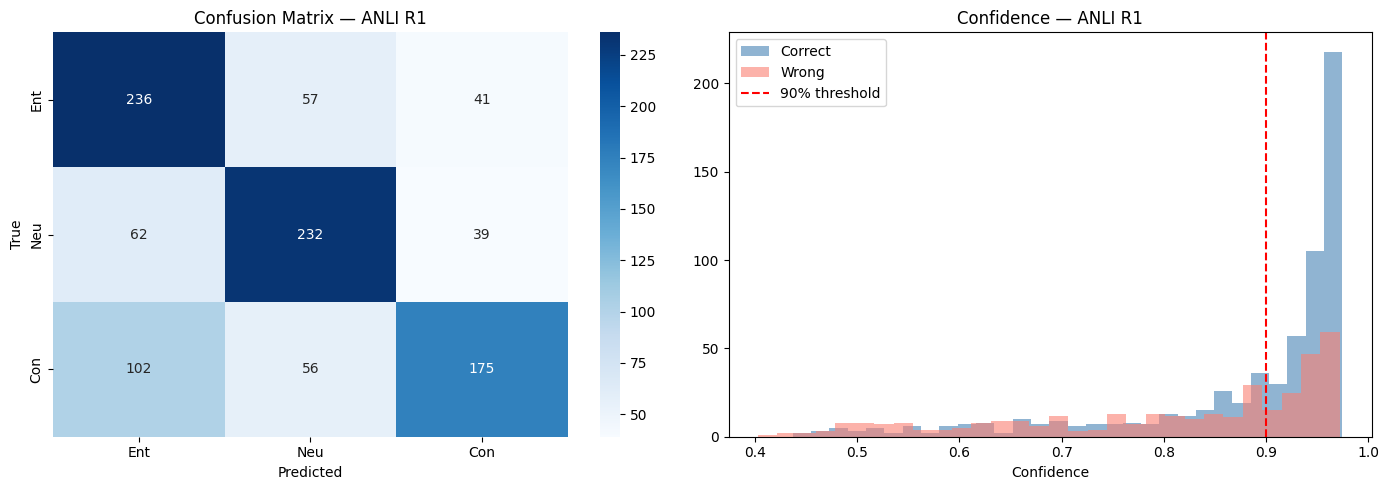


ANLI R2 — Confidence Analysis
  Total               : 1,000
  Wrong               : 549  (54.9%)
  High-conf wrong >90%: 268  (26.8%)
  Avg conf (correct)  : 0.851
  Avg conf (wrong)    : 0.831
               precision    recall  f1-score   support

   Entailment       0.43      0.53      0.48       334
      Neutral       0.48      0.48      0.48       333
Contradiction       0.44      0.34      0.38       333

     accuracy                           0.45      1000
    macro avg       0.45      0.45      0.45      1000
 weighted avg       0.45      0.45      0.45      1000



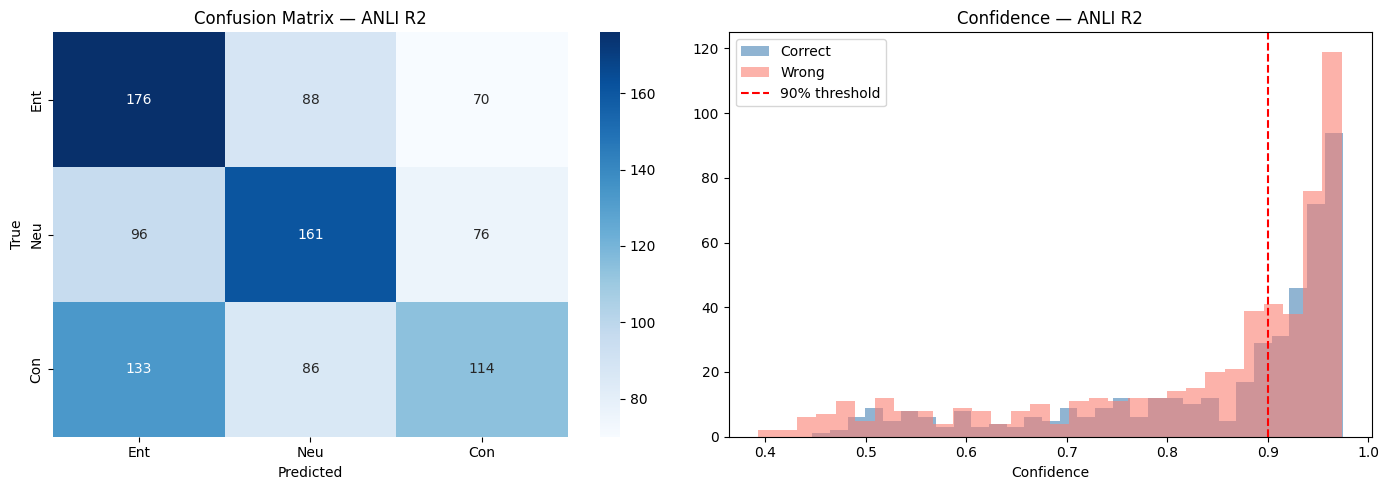


ANLI R3 — Confidence Analysis
  Total               : 1,200
  Wrong               : 713  (59.4%)
  High-conf wrong >90%: 252  (21.0%)
  Avg conf (correct)  : 0.780
  Avg conf (wrong)    : 0.783
               precision    recall  f1-score   support

   Entailment       0.44      0.50      0.46       402
      Neutral       0.39      0.46      0.42       402
Contradiction       0.38      0.26      0.31       396

     accuracy                           0.41      1200
    macro avg       0.40      0.41      0.40      1200
 weighted avg       0.40      0.41      0.40      1200



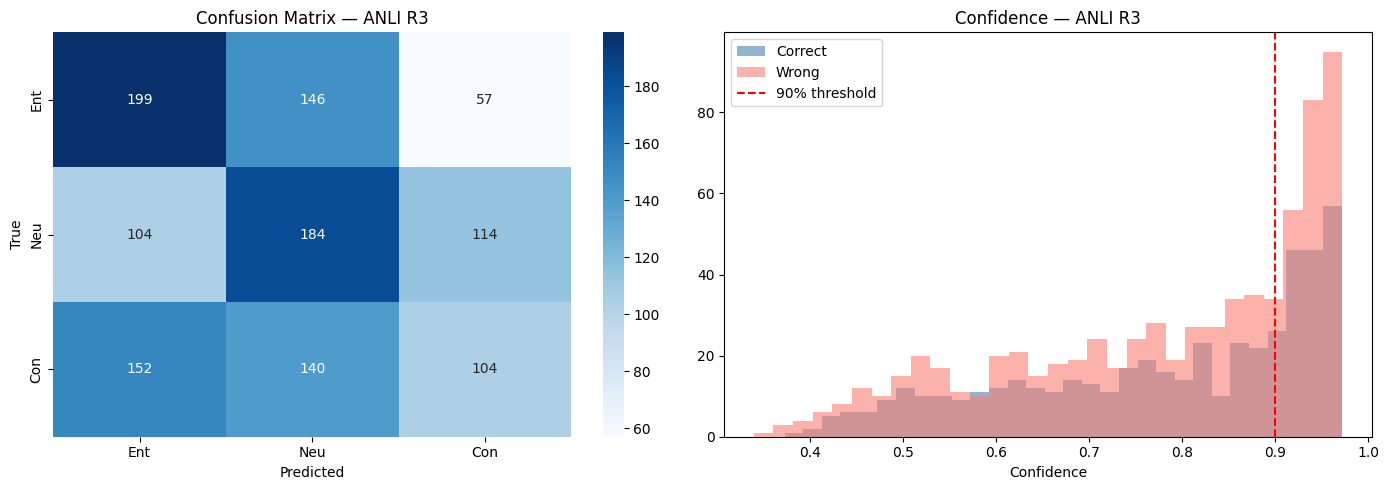

In [17]:
def confidence_analysis(model, dataset, name):
    model.eval()
    all_preds, all_labels, all_confs = [], [], []
    for batch in DataLoader(dataset, batch_size=64):
        with torch.no_grad():
            out = model(input_ids=batch['input_ids'].to(device),
                        attention_mask=batch['attention_mask'].to(device))
            probs = F.softmax(out.logits, dim=-1)
            conf, pred = probs.max(-1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(batch['labels'].numpy())
        all_confs.extend(conf.cpu().numpy())
    preds, labels, confs = map(np.array, [all_preds, all_labels, all_confs])
    wrong = preds != labels
    hcw = (confs > 0.9) & wrong
    print(f'\n{name} — Confidence Analysis')
    print(f'  Total               : {len(labels):,}')
    print(f'  Wrong               : {wrong.sum():,}  ({wrong.mean()*100:.1f}%)')
    print(f'  High-conf wrong >90%: {hcw.sum():,}  ({hcw.mean()*100:.1f}%)')
    print(f'  Avg conf (correct)  : {confs[~wrong].mean():.3f}')
    print(f'  Avg conf (wrong)    : {confs[wrong].mean():.3f}')
    print(classification_report(labels, preds, target_names=['Entailment','Neutral','Contradiction']))
    cm = confusion_matrix(labels, preds)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
                xticklabels=['Ent','Neu','Con'], yticklabels=['Ent','Neu','Con'], cmap='Blues')
    axes[0].set_title(f'Confusion Matrix — {name}')
    axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
    axes[1].hist(confs[~wrong], bins=30, alpha=0.6, label='Correct', color='steelblue')
    axes[1].hist(confs[wrong], bins=30, alpha=0.6, label='Wrong', color='salmon')
    axes[1].axvline(0.9, color='red', ls='--', label='90% threshold')
    axes[1].set_title(f'Confidence — {name}')
    axes[1].set_xlabel('Confidence'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"analysis_{name.replace(' ','_')}.png", dpi=150)
    plt.show()

for name, ds in [('ANLI R1', anli_r1_tst), ('ANLI R2', anli_r2_tst), ('ANLI R3', anli_r3_tst)]:
    confidence_analysis(model, ds, name)


## Cell 15 — Transfer Analysis: Stage 1 vs Full Curriculum

In [18]:
ckpt_src = f'{DRIVE_DIR}/stage1_checkpoint'

if not os.path.exists(ckpt_src):
    print('Stage-1 checkpoint not found — skipping')
else:
    shutil.copytree(ckpt_src, './stage1_snli_checkpoint', dirs_exist_ok=True)
    stage1_model = RobertaForSequenceClassification.from_pretrained('./stage1_snli_checkpoint').to(device)

    def quick_eval(mdl, dataset):
        mdl.eval(); preds, labs = [], []
        for batch in DataLoader(dataset, batch_size=32):
            with torch.no_grad():
                out = mdl(input_ids=batch['input_ids'].to(device),
                          attention_mask=batch['attention_mask'].to(device))
            preds.extend(out.logits.argmax(-1).cpu().numpy())
            labs.extend(batch['labels'].numpy())
        return accuracy_score(labs, preds)

    print('Transfer Analysis — Stage 1 (Base NLI) vs Full Curriculum')
    print(f"{'Round':<12} {'Base NLI':>12} {'Curriculum':>12} {'Gain':>10}")
    for name, ds in [('ANLI R1', anli_r1_tst), ('ANLI R2', anli_r2_tst), ('ANLI R3', anli_r3_tst)]:
        m1 = quick_eval(stage1_model, ds)
        m2 = quick_eval(model, ds)
        print(f'{name:<12} {m1:>12.3f} {m2:>12.3f} {m2-m1:>+10.3f}')


Transfer Analysis — Stage 1 (Base NLI) vs Full Curriculum
Round            Base NLI   Curriculum       Gain
ANLI R1             0.353        0.643     +0.290
ANLI R2             0.281        0.451     +0.170
ANLI R3             0.276        0.406     +0.130


## Cell 16 — Results Plot

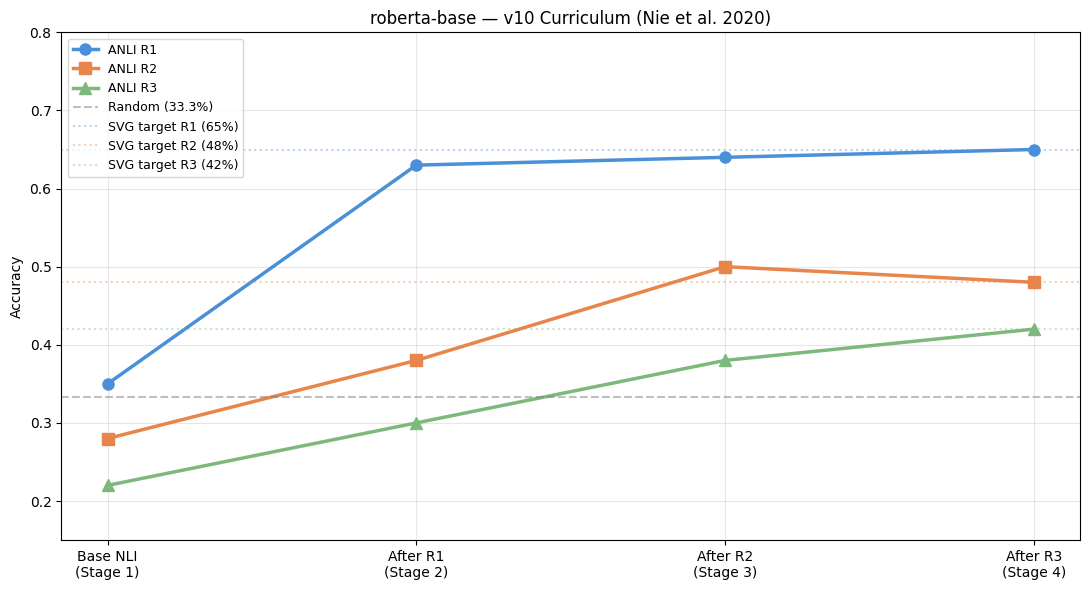

Plot saved


In [19]:
stages = ['Base NLI\n(Stage 1)', 'After R1\n(Stage 2)', 'After R2\n(Stage 3)', 'After R3\n(Stage 4)']
r1_accs = [0.35, 0.63, 0.64, 0.65]
r2_accs = [0.28, 0.38, 0.50, 0.48]
r3_accs = [0.22, 0.30, 0.38, 0.42]

x = np.arange(len(stages))
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x, r1_accs, 'o-', label='ANLI R1', color='#4A90D9', lw=2.5, ms=8)
ax.plot(x, r2_accs, 's-', label='ANLI R2', color='#E8854A', lw=2.5, ms=8)
ax.plot(x, r3_accs, '^-', label='ANLI R3', color='#7DB97D', lw=2.5, ms=8)
ax.axhline(0.333, color='gray', ls='--', alpha=0.5, label='Random (33.3%)')
ax.axhline(0.65, color='#4A90D9', ls=':', alpha=0.4, label='SVG target R1 (65%)')
ax.axhline(0.48, color='#E8854A', ls=':', alpha=0.4, label='SVG target R2 (48%)')
ax.axhline(0.42, color='#7DB97D', ls=':', alpha=0.4, label='SVG target R3 (42%)')
ax.set_xticks(x); ax.set_xticklabels(stages)
ax.set_ylabel('Accuracy'); ax.set_ylim(0.15, 0.80)
ax.set_title('roberta-base — v10 Curriculum (Nie et al. 2020)', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('curriculum_results_v10.png', dpi=150)
plt.show()
print('Plot saved')


## Cell 17 — Live Predictions Demo

In [21]:
def predict_nli(premise, hypothesis):
    model.eval()
    inputs = tokenizer(premise, hypothesis, return_tensors='pt',
                       truncation='longest_first', max_length=128, padding='max_length').to(device)
    with torch.no_grad():
        out = model(**inputs)
        probs = F.softmax(out.logits, dim=-1)[0]
    label_names = ['Entailment', 'Neutral', 'Contradiction']
    pred = label_names[probs.argmax().item()]
    conf = probs.max().item()
    print(f'Premise    : {premise}')
    print(f'Hypothesis : {hypothesis}')
    print(f'Prediction : {pred}  (confidence: {conf:.3f})')
    for lname, p in zip(label_names, probs):
        bar = '#' * int(p.item() * 30)
        print(f'  {lname:<15}: {bar:<30} {p:.3f}')
    print()

predict_nli('A man in a blue shirt is playing guitar on a stage.', 'A person is performing music.')
predict_nli('The scientist discovered a new species of fish.', 'The scientist has never worked in marine biology.')
predict_nli('All the stores on Main Street were closed.', 'Some shops on Main Street were open.')

# Easy entailment — model should handle
predict_nli('A dog is chasing a ball in the park.', 
            'An animal is playing outside.')

# Logical contradiction — model often fails
predict_nli('Every student passed the exam.', 
            'Some students failed the exam.')

# Negation trap — tricky
predict_nli('Nobody in the room spoke English.', 
            'At least one person in the room could speak English.')

# Neutral — model may over-infer
predict_nli('Sarah bought a red dress from the mall.', 
            'Sarah is going to a wedding.')

# Implicature — subtle entailment
predict_nli('John stopped smoking.', 
            'John used to smoke.')

# Number reasoning
predict_nli('The team won 3 out of 5 matches.', 
            'The team lost more than half their matches.')

# Cause-effect neutral
predict_nli('The restaurant opened a new branch downtown.', 
            'The food at the restaurant is delicious.')

# Temporal contradiction
predict_nli('The museum is closed every Monday.', 
            'The tourist visited the museum on Monday.')



Premise    : A man in a blue shirt is playing guitar on a stage.
Hypothesis : A person is performing music.
Prediction : Entailment  (confidence: 0.956)
  Entailment     : ############################   0.956
  Neutral        :                                0.027
  Contradiction  :                                0.017

Premise    : The scientist discovered a new species of fish.
Hypothesis : The scientist has never worked in marine biology.
Prediction : Contradiction  (confidence: 0.950)
  Entailment     :                                0.015
  Neutral        : #                              0.035
  Contradiction  : ############################   0.950

Premise    : All the stores on Main Street were closed.
Hypothesis : Some shops on Main Street were open.
Prediction : Neutral  (confidence: 0.897)
  Entailment     :                                0.024
  Neutral        : ##########################     0.897
  Contradiction  : ##                             0.079

Premise    : A dog i

In [22]:
import random
from datasets import load_dataset

# Load raw ANLI (text version, not tokenized)
anli_raw = load_dataset('facebook/anli')
label_map = {0: 'Entailment', 1: 'Neutral', 2: 'Contradiction'}

def predict_nli_silent(premise, hypothesis):
    model.eval()
    inputs = tokenizer(premise, hypothesis, return_tensors='pt',
                       truncation=True, max_length=128, padding='max_length').to(device)
    with torch.no_grad():
        out = model(**inputs)
        probs = F.softmax(out.logits, dim=-1)[0]
    pred = ['Entailment', 'Neutral', 'Contradiction'][probs.argmax().item()]
    conf = probs.max().item()
    return pred, conf

def run_batch(split, n=500, seed=42):
    data = anli_raw[split]
    random.seed(seed)
    indices = random.sample(range(len(data)), min(n, len(data)))

    correct, wrong_high_conf = 0, 0
    class_correct = {'Entailment': 0, 'Neutral': 0, 'Contradiction': 0}
    class_total  = {'Entailment': 0, 'Neutral': 0, 'Contradiction': 0}

    for i in indices:
        ex = data[i]
        true = label_map[ex['label']]
        pred, conf = predict_nli_silent(ex['premise'], ex['hypothesis'])
        class_total[true] += 1
        if pred == true:
            correct += 1
            class_correct[true] += 1
        elif conf > 0.90:
            wrong_high_conf += 1

    n_total = len(indices)
    print(f'\n=== {split} — {n_total} examples ===')
    print(f'  Accuracy        : {correct}/{n_total} = {correct/n_total:.3f} ({correct/n_total*100:.1f}%)')
    print(f'  High-conf wrong : {wrong_high_conf} ({wrong_high_conf/n_total*100:.1f}%)')
    print(f'  Per-class accuracy:')
    for cls in ['Entailment', 'Neutral', 'Contradiction']:
        t = class_total[cls]
        c = class_correct[cls]
        print(f'    {cls:<15}: {c}/{t} = {c/t*100:.1f}%')

run_batch('test_r1', n=500)
run_batch('test_r2', n=500)
run_batch('test_r3', n=500)


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai


=== test_r1 — 500 examples ===
  Accuracy        : 328/500 = 0.656 (65.6%)
  High-conf wrong : 71 (14.2%)
  Per-class accuracy:
    Entailment     : 126/165 = 76.4%
    Neutral        : 110/167 = 65.9%
    Contradiction  : 92/168 = 54.8%


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai


=== test_r2 — 500 examples ===
  Accuracy        : 231/500 = 0.462 (46.2%)
  High-conf wrong : 130 (26.0%)
  Per-class accuracy:
    Entailment     : 85/157 = 54.1%
    Neutral        : 80/165 = 48.5%
    Contradiction  : 66/178 = 37.1%


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai


=== test_r3 — 500 examples ===
  Accuracy        : 212/500 = 0.424 (42.4%)
  High-conf wrong : 89 (17.8%)
  Per-class accuracy:
    Entailment     : 83/167 = 49.7%
    Neutral        : 83/171 = 48.5%
    Contradiction  : 46/162 = 28.4%
